In [ ]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from src.models.baseline_lstm import BaselineLSTM

df = pd.read_csv('data/processed/AAPL_features.csv')

features_to_use = [col for col in df.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'target']]
X_df = df[features_to_use]
y_series = df[['target']] 

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

X_scaled = scaler_features.fit_transform(X_df)
y_scaled = scaler_target.fit_transform(y_series)

X, y = [], []
sequence_length = 30
for i in range(len(X_scaled) - sequence_length):
    X.append(X_scaled[i:i + sequence_length])
    y.append(y_scaled[i + sequence_length]) 

X = np.array(X)
y = np.array(y).reshape(-1, 1) 

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = BaselineLSTM(input_size=X.shape[2], hidden_size=64, num_layers=2, output_size=1)

In [ ]:

num_samples_train = X_train.shape[0]
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

X_train_flat_full = X_train.reshape(num_samples_train, sequence_length * num_features)
X_test_flat_full = X_test.reshape(X_test.shape[0], sequence_length * num_features)

y_test_unscaled = scaler_target.inverse_transform(y_test)

In [ ]:

X_train_flat = X_train[:, -1, :]
X_test_flat = X_test[:, -1, :]


y_test_unscaled = scaler_target.inverse_transform(y_test)

--- Linear Regression Results ---
RMSE: 9.21
R-squared: 0.0764


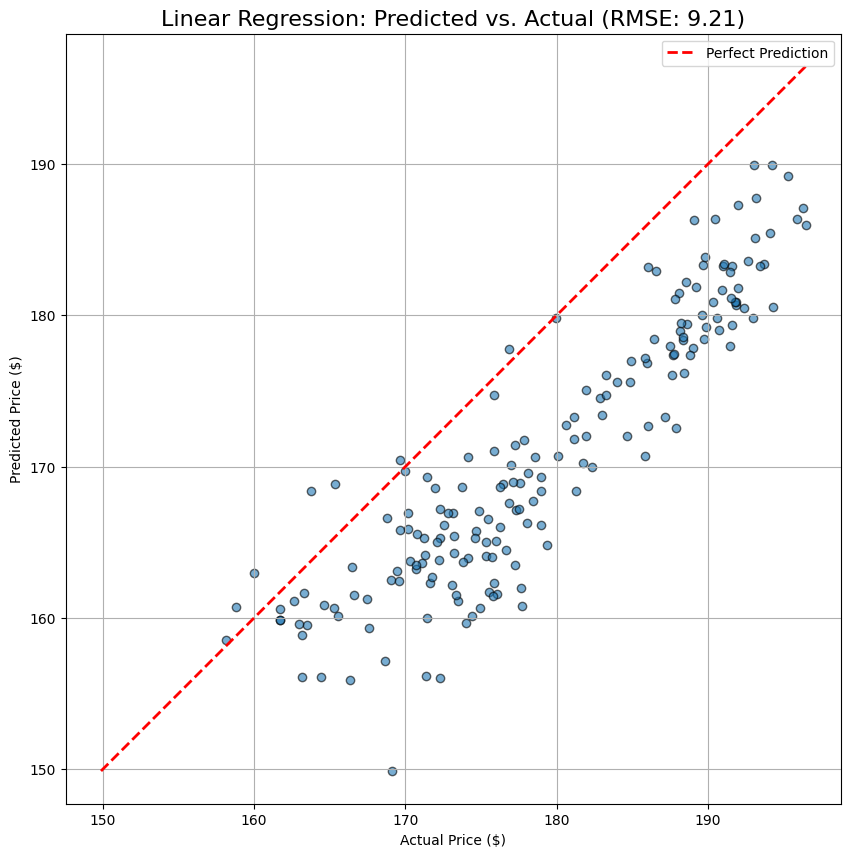

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

lr_model = LinearRegression()
lr_model.fit(X_train_flat_full, y_train.ravel()) 

lr_predictions_scaled = lr_model.predict(X_test_flat_full)

lr_predictions = scaler_target.inverse_transform(lr_predictions_scaled.reshape(-1, 1))

lr_rmse = np.sqrt(mean_squared_error(y_test_unscaled, lr_predictions))
lr_r2 = r2_score(y_test_unscaled, lr_predictions)

print("--- Linear Regression Results ---")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R-squared: {lr_r2:.4f}")


import matplotlib.pyplot as plt


plt.figure(figsize=(10, 10))

plt.scatter(y_test_unscaled, lr_predictions, alpha=0.6, edgecolor='k')

min_val = min(y_test_unscaled.min(), lr_predictions.min())
max_val = max(y_test_unscaled.max(), lr_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title(f'Linear Regression: Predicted vs. Actual (RMSE: {lr_rmse:.2f})', fontsize=16)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [ ]:
X_train_flat = X_train[:, -1, :]
X_test_flat = X_test[:, -1, :]

y_test_unscaled = scaler_target.inverse_transform(y_test)


--- Random Forest Results ---
RMSE: 13.21
R-squared: -0.9025


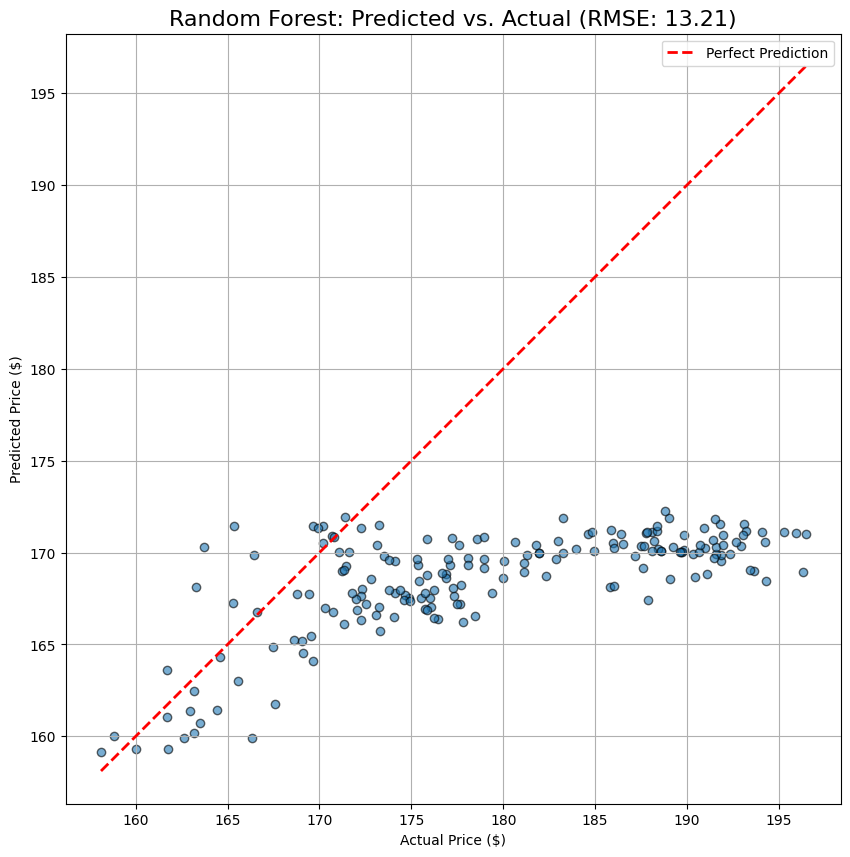

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_flat, y_train.ravel())

rf_predictions_scaled = rf_model.predict(X_test_flat)

rf_predictions = scaler_target.inverse_transform(rf_predictions_scaled.reshape(-1, 1))

rf_rmse = np.sqrt(mean_squared_error(y_test_unscaled, rf_predictions))
rf_r2 = r2_score(y_test_unscaled, rf_predictions)

print("--- Random Forest Results ---")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R-squared: {rf_r2:.4f}")

plt.figure(figsize=(10, 10))

plt.scatter(y_test_unscaled, rf_predictions, alpha=0.6, edgecolor='k')

min_val = min(y_test_unscaled.min(), rf_predictions.min())
max_val = max(y_test_unscaled.max(), rf_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')


plt.title(f'Random Forest: Predicted vs. Actual (RMSE: {rf_rmse:.2f})', fontsize=16)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.axis('equal') 
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from src.models.enhanced_lstm import EnhancedLSTM 

# --- 1. Define Hyperparameters ---
sequence_length = 60
hidden_size = 128
num_layers = 3
learning_rate = 0.001
num_epochs = 50
batch_size = 64

# --- 2. Data Preparation (for All Features) ---
df = pd.read_csv('data/processed/AAPL_features.csv')

features_to_use = [col for col in df.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'target']]
X_df = df[features_to_use]
y_series = df[['target']]


X, y = [], []
for i in range(len(X_df) - sequence_length):
    X.append(X_df.iloc[i:i + sequence_length].values)
    y.append(y_series.iloc[i + sequence_length].values)
X, y = np.array(X), np.array(y)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[:train_size:]
y_train, y_test = y[:train_size], y[:train_size:]

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

# Reshape X_train to 2D to fit the scaler
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler_features.fit(X_train_reshaped)
scaler_target.fit(y_train)

# Transform both train and test sets
X_train_scaled = scaler_features.transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler_features.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_train_scaled = scaler_target.transform(y_train)
y_test_scaled = scaler_target.transform(y_test)


# --- 3. Dataloaders ---
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# --- 4. Model, Loss, Optimizer ---
input_size = X_train_scaled.shape[2]
enhanced_model = EnhancedLSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, output_size=1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(enhanced_model.parameters(), lr=learning_rate, weight_decay=1e-5)

# --- 5. Training Loop ---
print(f"\nTraining LSTM model.")
for epoch in range(num_epochs):
    enhanced_model.train()
    for inputs, labels in train_loader:
        outputs = enhanced_model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
print("Training finished.")

# --- 6. Evaluation ---
enhanced_model.eval()
with torch.no_grad():
    predictions_scaled = enhanced_model(X_test_tensor)

predictions_unscaled = scaler_target.inverse_transform(predictions_scaled.cpu().numpy())
actuals_unscaled = scaler_target.inverse_transform(y_test_scaled)

rmse = np.sqrt(mean_squared_error(actuals_unscaled, predictions_unscaled))
r2 = r2_score(actuals_unscaled, predictions_unscaled)

print(f"\n---  LSTM Results ---")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.4f}")


Training LSTM model.
Training finished.

---  LSTM Results ---
RMSE: 4.81
R-squared: 0.9452


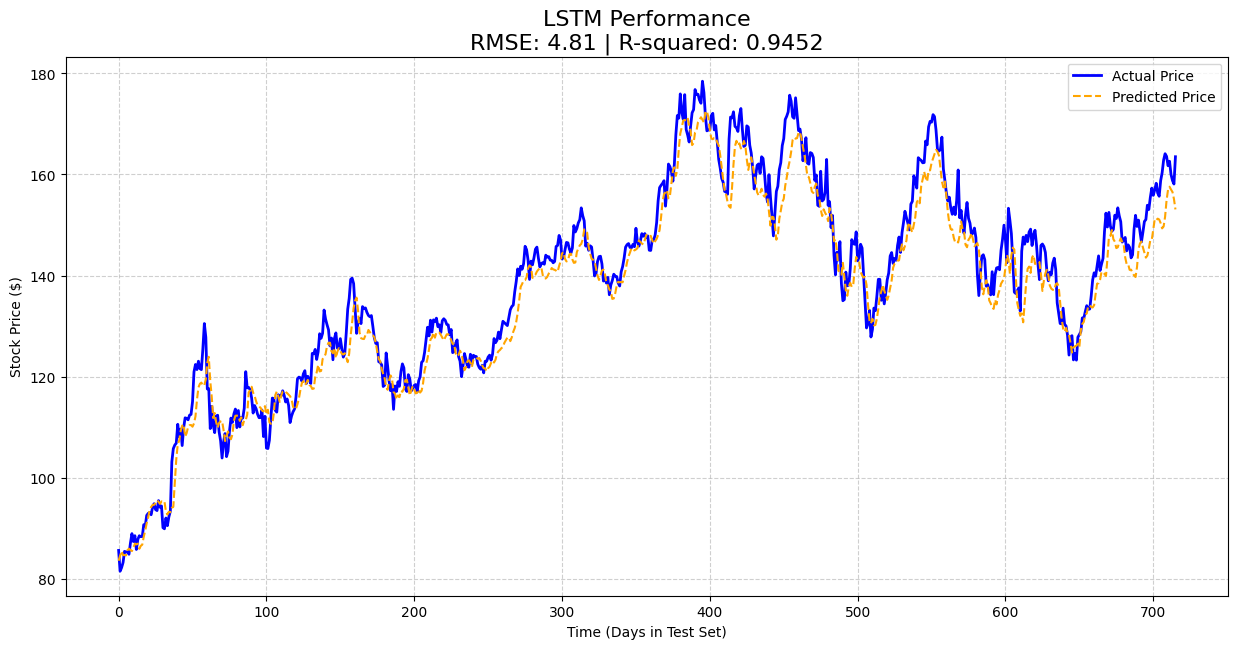

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 7))

plt.plot(actuals_unscaled, label='Actual Price', color='blue', linewidth=2)
plt.plot(predictions_unscaled, label='Predicted Price', color='orange', linestyle='--')

plt.title(f'LSTM Performance\nRMSE: {rmse:.2f} | R-squared: {r2:.4f}', fontsize=16)
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd

comparison_results = {
    'Linear Regression': {
        'RMSE': lr_rmse,
        'R-squared': lr_r2
    },
    'Random Forest': {
        'RMSE': rf_rmse,
        'R-squared': rf_r2
    },
      ' LSTM ': {
        'RMSE': rmse,     
        'R-squared': r2   
    }
}

results_df = pd.DataFrame(comparison_results).T
results_df = results_df.sort_values(by='RMSE', ascending=True)

print("--- Final Model Comparison ---")
print(results_df)

--- Final Model Comparison ---
                        RMSE  R-squared
 LSTM               4.812487   0.945154
Linear Regression   9.206410   0.076385
Random Forest      13.213027  -0.902457
